In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from bleed_masking import bleed_masking

## Generating the bleeding masks for the 1084 field of KS4. 

In [3]:
path_KMTNet_CTIO_N_img = 'data/ks4.1084.179-34.I.dith0.kmtc.20210407.022071.nn.fits'
path_KMTNet_CTIO_T_img = 'data/ks4.1084.179-34.I.dith0.kmtc.20210407.022071.tt.fits'

# Saturation threshold is set to 50000 for every single-epoch images except for T chip in CTIO, which is set to 40000
bleed_mask_CTIO_N = bleed_masking(path_KMTNet_CTIO_N_img, bleeding_thres=50000, BI_thres=500, detect_thres=0.4, CL=6, flagval=1)
bleed_mask_CTIO_T = bleed_masking(path_KMTNet_CTIO_T_img, bleeding_thres=40000, BI_thres=500, detect_thres=0.4, CL=6, flagval=1)

## Comparing the image and the generated bleeding mask.


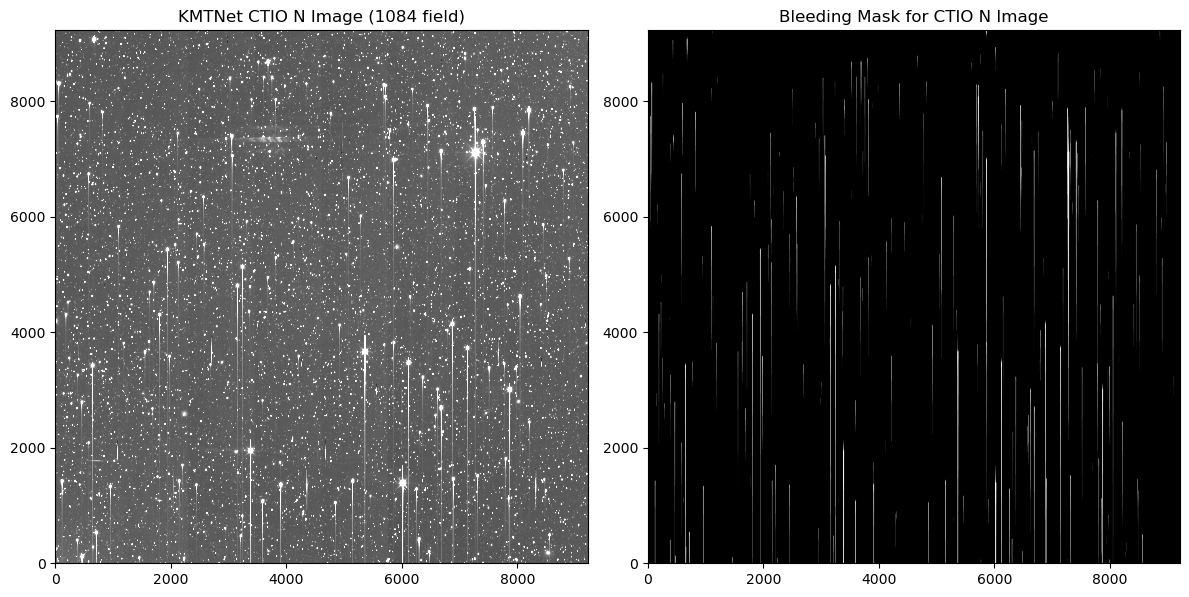

In [4]:
# CTIO N chip

KMTNet_CTIO_N_img = fits.getdata(path_KMTNet_CTIO_N_img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
vmin_N, vmax_N = ZScaleInterval().get_limits(KMTNet_CTIO_N_img)
plt.imshow(KMTNet_CTIO_N_img, cmap='gray', vmin=vmin_N, vmax=vmax_N, origin='lower')
plt.title('KMTNet CTIO N Image (1084 field)')
plt.subplot(1, 2, 2)
plt.imshow(bleed_mask_CTIO_N, cmap='gray', origin='lower')
plt.title('Bleeding Mask for CTIO N Image')
plt.tight_layout()
plt.show()

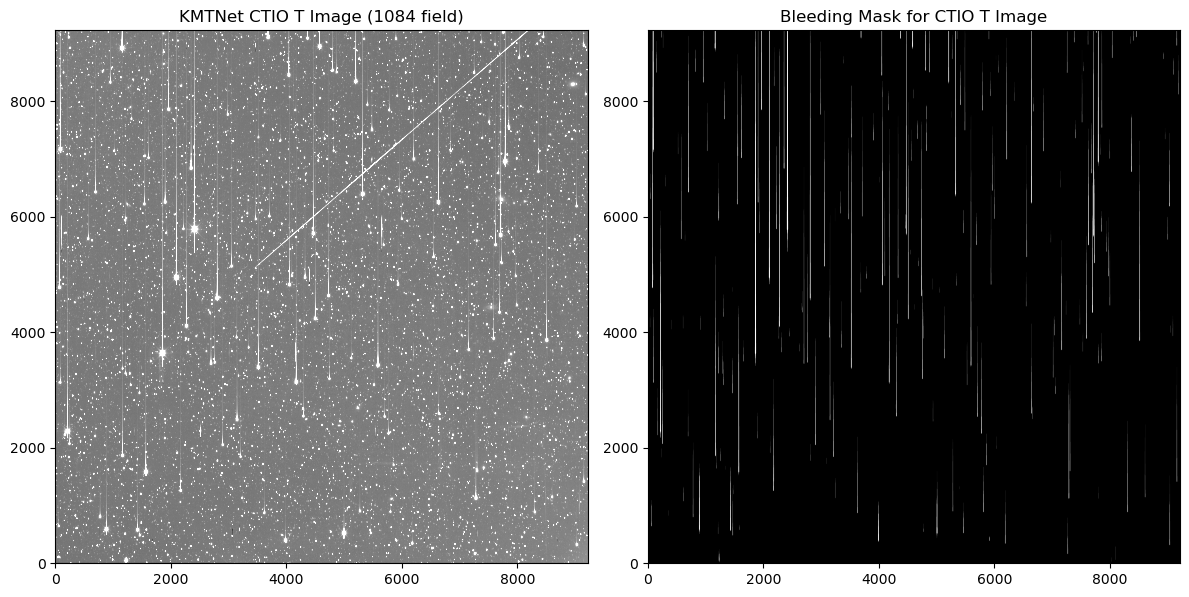

In [5]:
# CTIO T chip

KMTNet_CTIO_T_img = fits.getdata(path_KMTNet_CTIO_T_img)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
vmin_T, vmax_T = ZScaleInterval().get_limits(KMTNet_CTIO_T_img)
plt.imshow(KMTNet_CTIO_T_img, cmap='gray', vmin=vmin_T, vmax=vmax_T, origin='lower')
plt.title('KMTNet CTIO T Image (1084 field)')
plt.subplot(1, 2, 2)
plt.imshow(bleed_mask_CTIO_T, cmap='gray', origin='lower')
plt.title('Bleeding Mask for CTIO T Image')
plt.tight_layout()
plt.show()

In [ ]:
def bleed_masking(datapath,  bleeding_thres=50000, BI_thres=500, detect_thres=0.4, CL=6, flagval=4):
    
    import os
    import numpy as np
    from astropy.stats import sigma_clipped_stats
    from astropy.io import fits
    
    Msg.bleedmap()
    hdul    = fits.open(datapath)
    data    = hdul[0].data
    hdr     = hdul[0].header
    leny, lenx = data.shape
    bleeding_mask = np.zeros_like(data)
    _, med, sig = sigma_clipped_stats(data)
    signal_thres = med + detect_thres * sig

    chip    = os.path.basename(datapath).split(".")[1]

    # Determine the direction of masking based on the chip type
    if chip in ['kk', 'nn']:
        direction = 'downward'
    elif chip in ['mm', 'tt']:
        direction = 'upward'
    else:
        raise ValueError("Unknown chip type")

    for i in range(lenx):
        col = data[:, i]
        sat_indices = np.where(col > bleeding_thres)[0]

        for y_idx in sat_indices:
            if bleeding_mask[y_idx, i] == flagval:
                continue  # Skip already marked pixels

            # Calculate the sum of pixel values in the vicinity to determine if there is actual bleeding
            if direction == 'downward':
                ystart = max(y_idx - 40, 0)
                yend = max(y_idx - 20, 0)
            else:  # 'upward'
                ystart = min(y_idx + 20, leny - 1)
                yend = min(y_idx + 40, leny - 1)

            if ystart < yend:
                bpidx = np.sum(data[ystart:yend+1, i])
                ylength = yend - ystart + 1
                if bpidx - med * ylength > BI_thres:
                    bleeding_mask[y_idx, i] = flagval  # Set mask only if the condition is met
                    revert_pixel = 0

                    # Define scanning range based on direction
                    range_start, range_end, step = (y_idx, -1, -1) if direction == 'downward' else (y_idx, leny, 1)

                    # Scan through the column in the specified direction
                    for j in range(range_start, range_end, step):
                        if col[j] > signal_thres:
                            bleeding_mask[j, i] = flagval
                            revert_pixel = 0
                        else:
                            bleeding_mask[j, i] = flagval
                            revert_pixel += 1

                        # Stop marking when enough consecutive small values are found
                        if revert_pixel >= CL:
                            if direction == 'downward':
                                end_idx = max(j - CL, 0)
                            else:
                                end_idx = min(j + CL, leny)
                            bleeding_mask[j:end_idx, i] = 0
                            break
    # Save the mask
    # fits.PrimaryHDU(data=bleeding_mask, header=hdr).writeto(datapath.replace('.fits', '.bmask.fits'), overwrite=True)
    return bleeding_mask